https://github.com/shivam1808/Recommendation-System

In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import root_mean_squared_error
from scipy.sparse import csr_matrix
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('final_processed_data.csv')
df.drop(columns='Unnamed: 0', inplace=True)
df.head()

,Restaurant Name,Cuisine Type,Restaurant Rating,Location,Price,Username,User Rating,User Review
0,Momo Paradise,Jepang,4.73,Kelapa Gading,Di atas Rp. 200.000 /orang,micky_ardhienoor_husin,4.8,One of my bucket list\nPenasaran pgn makan di ...
1,Momo Paradise,Jepang,4.73,Kelapa Gading,Di atas Rp. 200.000 /orang,rebecca_t,4.8,One of the Best Japanese Hotpot\nKayaknya Momo...
2,Momo Paradise,Jepang,4.73,Kelapa Gading,Di atas Rp. 200.000 /orang,foodbuddies.id,4.8,The Best Authentic Japanese Sukiyaki & Shabu-S...
3,Momo Paradise,Jepang,4.73,Kelapa Gading,Di atas Rp. 200.000 /orang,antihungryclub,5.0,AYCE Authentic khas Jepang\nMomo Paradise -- T...
4,Momo Paradise,Jepang,4.73,Kelapa Gading,Di atas Rp. 200.000 /orang,fitriahlaela,5.0,AYCE yg worth it!!\nAYCE yang menyenangkan dan...


In [2]:
# normalize
min_rating = df['User Rating'].min()
max_rating = df['User Rating'].max()

df['Rating Normalize'] = (df['User Rating'] - min_rating) / (max_rating - min_rating)

print(f"Minimum of normalized User Rating: {df['Rating Normalize'].min()}")
print(f"Maximum of normalized User Rating: {df['Rating Normalize'].max()}")

Minimum of normalized User Rating: 0.0
Maximum of normalized User Rating: 1.0


In [3]:
rating_data_df = df[['Username', 'Restaurant Name', 'Rating Normalize']].copy()

user_encoder = LabelEncoder()
resto_encoder = LabelEncoder()

rating_data_df['User ID'] = user_encoder.fit_transform(rating_data_df['Username'])
rating_data_df['Restaurant ID'] = resto_encoder.fit_transform(rating_data_df['Restaurant Name'])

rating_data_df = rating_data_df[['User ID', 'Restaurant ID', 'Rating Normalize']]

In [4]:
rating_data_df

,User ID,Restaurant ID,Rating Normalize
0,2287,615,0.95
1,2672,615,0.95
2,1507,615,0.95
3,712,615,1.00
4,1497,615,1.00
...,...,...,...
28146,375,41,0.50
28147,2936,41,0.85
28148,160,41,1.00
28149,381,41,0.75


In [5]:
from sklearn.model_selection import train_test_split
trainval_df, test_df = train_test_split(rating_data_df, test_size=0.1, random_state=42)
train_df, val_df = train_test_split(trainval_df, test_size=0.125, random_state=42)

print(f"Total Training Data: {len(train_df)}")
print(f"Total Validation Data: {len(val_df)}")
print(f"Total Testing Data: {len(test_df)}")
print(train_df.shape)
print(test_df.shape)
print(val_df.shape)

Total Training Data: 22168
Total Validation Data: 3167
Total Testing Data: 2816
(22168, 3)
(2816, 3)
(3167, 3)


In [6]:
# pivot untuk train aja
ratings_matrix_train = train_df.pivot_table(index='User ID', columns='Restaurant ID', values='Rating Normalize').fillna(0)

In [7]:
ratings_matrix_train

Restaurant ID,0,1,2,3,4,5,6,7,8,9,...,1036,1037,1038,1039,1040,1041,1042,1043,1044,1045
User ID,,,,,,,,,,,,,,,,,,,,,
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3376,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3377,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3378,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


cosine similarity\
Cosine similarity is a measure of similarity between two vectors in a multi-dimensional space. It is defined as the dot product of the two vectors divided by the product of their magnitudes (lengths).

adjusted cosine similarity\
Adjusted cosine similarity is a variation of cosine similarity that takes into account the differences in rating scales between users. It is commonly used in recommender systems to compare the similarity between users' ratings.

In [ ]:
adjusted_ratings = ratings_matrix_train.sub(ratings_matrix_train.mean(axis=1), axis=0).fillna(0) 
# subtracts each user's average rating from all their ratings
# kalo user biasanya rating tinggi (e.g., 4-5), bakal di "normalizes" ke 0-mean
# rumus ny : rating - user avg rating

sparse_matrix = csr_matrix(adjusted_ratings.T.values)
# csr_matrix = compressed sparse row matrix
# di convert ke sparse matrix spy lbh efisien krn bykan values 0 nya di data ini (sparse)
# Transpose untuk item-based CF (item-item), krn sblmny itu row = user ; col = restaurant gini
# stlh transpose jadi row = restaurant, spy bs calculate similarity between restaurant

similarity_matrix = cosine_similarity(sparse_matrix)
# cosine similarity : measure how similar items are based on user rating
# value ranges from -1 to 1 (dri -1 krn pakai adjusted cosine)
# mendekati 1 = more similar
# mendekati -1 = One item is liked when the other is disliked
# 0 = no correlation

similarity_df = pd.DataFrame(similarity_matrix, index=adjusted_ratings.columns, columns=adjusted_ratings.columns)
# convert ke dataframe spy lbh mudah dilihat

In [9]:
adjusted_ratings

Restaurant ID,0,1,2,3,4,5,6,7,8,9,...,1036,1037,1038,1039,1040,1041,1042,1043,1044,1045
User ID,,,,,,,,,,,,,,,,,,,,,
0,-0.001965,-0.001965,-0.001965,-0.001965,-0.001965,-0.001965,-0.001965,-0.001965,-0.001965,-0.001965,...,-0.001965,-0.001965,-0.001965,-0.001965,-0.001965,-0.001965,-0.001965,-0.001965,-0.001965,-0.001965
2,-0.002733,-0.002733,-0.002733,-0.002733,-0.002733,-0.002733,-0.002733,-0.002733,-0.002733,-0.002733,...,-0.002733,-0.002733,-0.002733,-0.002733,-0.002733,-0.002733,-0.002733,-0.002733,-0.002733,-0.002733
3,-0.000671,-0.000671,-0.000671,-0.000671,-0.000671,-0.000671,-0.000671,-0.000671,-0.000671,-0.000671,...,-0.000671,-0.000671,-0.000671,-0.000671,-0.000671,-0.000671,-0.000671,-0.000671,-0.000671,-0.000671
4,-0.000911,-0.000911,-0.000911,-0.000911,-0.000911,-0.000911,-0.000911,-0.000911,-0.000911,-0.000911,...,-0.000911,-0.000911,-0.000911,-0.000911,-0.000911,-0.000911,-0.000911,-0.000911,-0.000911,-0.000911
5,-0.001918,-0.001918,-0.001918,-0.001918,-0.001918,-0.001918,-0.001918,-0.001918,-0.001918,-0.001918,...,-0.001918,-0.001918,-0.001918,-0.001918,-0.001918,-0.001918,-0.001918,-0.001918,-0.001918,-0.001918
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3376,-0.001390,-0.001390,-0.001390,-0.001390,-0.001390,-0.001390,-0.001390,-0.001390,-0.001390,-0.001390,...,-0.001390,-0.001390,-0.001390,-0.001390,-0.001390,-0.001390,-0.001390,-0.001390,-0.001390,-0.001390
3377,-0.000767,-0.000767,-0.000767,-0.000767,-0.000767,-0.000767,-0.000767,-0.000767,-0.000767,-0.000767,...,-0.000767,-0.000767,-0.000767,-0.000767,-0.000767,-0.000767,-0.000767,-0.000767,-0.000767,-0.000767
3378,-0.000863,-0.000863,-0.000863,-0.000863,-0.000863,-0.000863,-0.000863,-0.000863,-0.000863,-0.000863,...,-0.000863,-0.000863,-0.000863,-0.000863,-0.000863,-0.000863,-0.000863,-0.000863,-0.000863,-0.000863


In [12]:
similarity_df

Restaurant ID,0,1,2,3,4,5,6,7,8,9,...,1036,1037,1038,1039,1040,1041,1042,1043,1044,1045
Restaurant ID,,,,,,,,,,,,,,,,,,,,,
0,1.000000,0.048333,-0.052943,0.045564,0.007809,-0.050319,-0.014048,0.105198,-0.053091,0.153924,...,-0.065453,-0.043687,-0.056407,-0.074559,0.049153,-0.077545,0.021464,-0.074284,-0.000620,0.013560
1,0.048333,1.000000,0.080771,-0.000612,0.081523,-0.041129,0.056179,0.043055,0.003981,0.034762,...,-0.038328,0.008880,-0.073804,-0.004222,-0.077867,-0.011552,0.051415,-0.052790,0.017500,-0.064391
2,-0.052943,0.080771,1.000000,-0.013271,-0.055659,0.079055,0.046839,0.164189,0.000786,-0.084997,...,0.175274,-0.072868,0.178204,-0.023935,-0.021129,-0.035473,-0.006270,0.023670,0.105693,-0.090873
3,0.045564,-0.000612,-0.013271,1.000000,-0.003155,-0.101539,-0.063041,0.120791,-0.041083,0.033710,...,-0.030228,-0.061021,-0.048277,-0.096602,0.092236,-0.114617,0.027564,-0.036157,0.071109,-0.072615
4,0.007809,0.081523,-0.055659,-0.003155,1.000000,-0.065151,-0.056224,0.028620,0.158438,0.269499,...,-0.086330,0.035182,-0.044737,-0.077936,-0.032396,-0.095922,-0.041764,-0.041112,0.023753,0.105504
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1041,-0.077545,-0.011552,-0.035473,-0.114617,-0.095922,0.009477,0.035089,-0.094740,-0.015824,-0.139502,...,-0.001761,0.100318,-0.028688,0.089832,-0.143191,1.000000,-0.011717,0.009310,-0.074554,-0.039827
1042,0.021464,0.051415,-0.006270,0.027564,-0.041764,0.027859,-0.012618,-0.041255,0.010647,-0.064762,...,0.024362,-0.047218,-0.070419,-0.004691,0.022866,-0.011717,1.000000,-0.050584,0.113934,-0.061330
1043,-0.074284,-0.052790,0.023670,-0.036157,-0.041112,-0.044308,0.134569,0.197138,0.016273,-0.076837,...,0.050792,0.052748,0.072560,0.017227,-0.087288,0.009310,-0.050584,1.000000,0.014611,-0.082763


In [13]:
# predicts the rating that a specific user would give to a specific item
# based on user's past rating, The similarity between the target item and the items they’ve already rated

def predict_rating_item_based(user, item, ratings_matrix, similarity_df, k=10):
    # find all item that have been rated in train set
    if user not in ratings_matrix.index or item not in ratings_matrix.columns:
        return np.nan
    # Get the list of items the user has rated
    user_ratings = ratings_matrix.loc[user]
    rated_items = user_ratings[user_ratings > 0].index

    # get similarity between target item and each item user has rated
    similarities = similarity_df.loc[item, rated_items]
    ratings = user_ratings[rated_items] # actual rating
    # weighted sum for rating prediction
    if similarities.abs().sum() == 0:
        return ratings.mean()  # fallback
    # If all similarities are 0, no information can be inferred → fallback to average of user's known ratings
    return np.dot(similarities, ratings) / (np.abs(similarities).sum() + 1e-8)
    # Weighted average prediction:
    # Numerator: dot product of similarity and rating → gives weighted contribution
    # Denominator: sum of absolute similarities → ensures proper scaling
    # 1e-8 is to prevent division by zero (safe fallback)

In [ ]:
from collections import defaultdict
import numpy as np

def evaluate_all_metrics(df_split, ratings_matrix_train, similarity_df, k=10):
    preds = []
    trues = []

    user_recs = defaultdict(list)
    truth = defaultdict(list)

    for user in df_split['User ID'].unique():
    # For each user in the validation/test set:
    # Find which items are unrated in the training set
    # Predict rating for each unrated item using your item-based CF
    # Store the Top-K highest-predicted items as recommendations
    # user_recs[user] = [item1, item2, ..., item_k]
    # the actual items the user rated in the test set : truth[user] = [actual items]

        if user not in ratings_matrix_train.index:
            continue
        rated_in_train = ratings_matrix_train.loc[user]
        unrated_items = rated_in_train[rated_in_train == 0].index

        scores = []
        for item in unrated_items:
            if item not in similarity_df.index:
                continue
            pred = predict_rating_item_based(user, item, ratings_matrix_train, similarity_df)
            if not np.isnan(pred):
                scores.append((item, pred))
        top_k = sorted(scores, key=lambda x: -x[1])[:k]
        user_recs[user] = [item for item, _ in top_k]

        # Ground truth for Precision/Recall
        actual_items = df_split[df_split['User ID'] == user]['Restaurant ID'].tolist()
        truth[user] = actual_items

    # RMSE / MAE
    used_rows = 0
    for _, row in df_split.iterrows():
    # For every (user, item, true_rating) pair in the test set:
    # Predict the rating using predict_rating_item_based
    # If the prediction is not NaN, store it for RMSE/MAE calculation
        user = row['User ID']
        item = row['Restaurant ID']
        true_rating = row['Rating Normalize']

        if user in ratings_matrix_train.index and item in similarity_df.index:
            pred = predict_rating_item_based(user, item, ratings_matrix_train, similarity_df)
            if not np.isnan(pred):
                preds.append(pred)
                trues.append(true_rating)
                used_rows += 1

    rmse = np.sqrt(np.mean((np.array(preds) - np.array(trues)) ** 2))
    mae = np.mean(np.abs(np.array(preds) - np.array(trues)))

    # Precision and Recall
    precisions = []
    recalls = []

    for user in truth:
        actual_items = set(truth[user])
        predicted_items = set(user_recs[user][:k])
        num_hits = len(actual_items & predicted_items)

        if len(predicted_items) > 0:
            precisions.append(num_hits / len(predicted_items))
        if len(actual_items) > 0:
            recalls.append(num_hits / len(actual_items))

    precision_at_k = np.mean(precisions) # average across all user
    recall_at_k = np.mean(recalls)

    return {
        'rmse': rmse,
        'mae': mae,
        'precision@k': precision_at_k,
        'recall@k': recall_at_k,
        'used_rows': used_rows,
        'total_rows': len(df_split),
        'coverage': used_rows / len(df_split)
    }


In [ ]:
k = 10

print("=== TRAIN SET ===")
train_metrics = evaluate_all_metrics(train_df, ratings_matrix_train, similarity_df, k)
print(train_metrics)

print("\n=== VALIDATION SET ===")
val_metrics = evaluate_all_metrics(val_df, ratings_matrix_train, similarity_df, k)
print(val_metrics)

print("\n=== TEST SET ===")
test_metrics = evaluate_all_metrics(test_df, ratings_matrix_train, similarity_df, k)
print(test_metrics)

# 15m 12s

=== TRAIN SET ===
{'rmse': np.float64(0.15954217356669612), 'mae': np.float64(0.10986590260408004), 'precision@k': np.float64(0.0), 'recall@k': np.float64(0.0), 'used_rows': 22167, 'total_rows': 22168, 'coverage': 0.9999548899314327}

=== VALIDATION SET ===
{'rmse': np.float64(0.6227350622470237), 'mae': np.float64(0.4835192568251938), 'precision@k': np.float64(0.02250922509225092), 'recall@k': np.float64(0.06552287758968382), 'used_rows': 2948, 'total_rows': 3167, 'coverage': 0.9308493842753395}

=== TEST SET ===
{'rmse': np.float64(0.6310080087229919), 'mae': np.float64(0.48934080092446414), 'precision@k': np.float64(0.015272244355909697), 'recall@k': np.float64(0.042452489173388404), 'used_rows': 2610, 'total_rows': 2816, 'coverage': 0.9268465909090909}


=== TRAIN SET ===\
{\
'rmse': np.float64(0.15954217356669612), \
'mae': np.float64(0.10986590260408004), \
'precision@k': np.float64(0.0), \
'recall@k': np.float64(0.0), \
'used_rows': 22167, \
'total_rows': 22168, \
'coverage': 0.9999548899314327\
}

=== VALIDATION SET ===\
{\
'rmse': np.float64(0.6227350622470237), \
'mae': np.float64(0.4835192568251938), \
'precision@k': np.float64(0.02250922509225092), \
'recall@k': np.float64(0.06552287758968382), \
'used_rows': 2948, \
'total_rows': 3167, \
'coverage': 0.9308493842753395\
}

=== TEST SET ===\
{\
'rmse': np.float64(0.6310080087229919), \
'mae': np.float64(0.48934080092446414), \
'precision@k': np.float64(0.015272244355909697), \
'recall@k': np.float64(0.042452489173388404), \
'used_rows': 2610, \
'total_rows': 2816, \
'coverage': 0.9268465909090909\
}

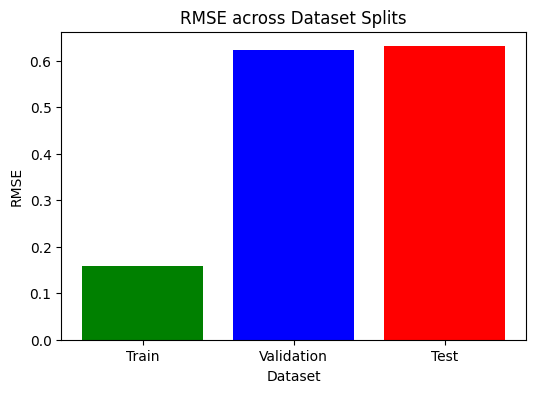

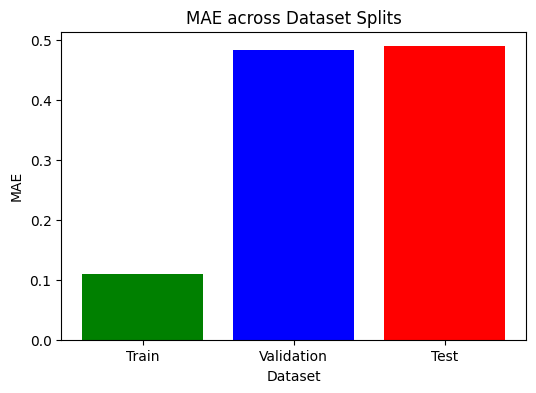

In [56]:
import matplotlib.pyplot as plt

results = {
    "Train": train_metrics,
    "Validation": val_metrics,
    "Test": test_metrics
}

error = ['rmse', 'mae']

for metric in error:
    values = [results[split][metric] for split in results]
    
    plt.figure(figsize=(6, 4))
    plt.bar(results.keys(), values, color=['green', 'blue', 'red'])
    plt.title(f"{metric.upper()} across Dataset Splits")
    plt.ylabel(metric.upper())
    plt.xlabel("Dataset")
    plt.show()


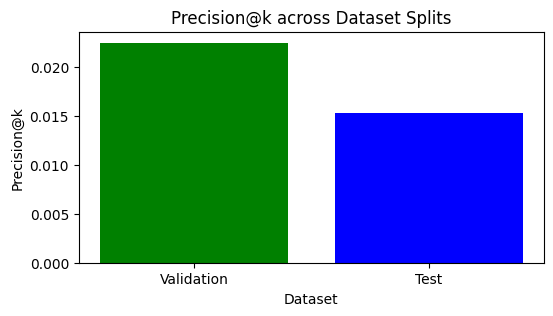

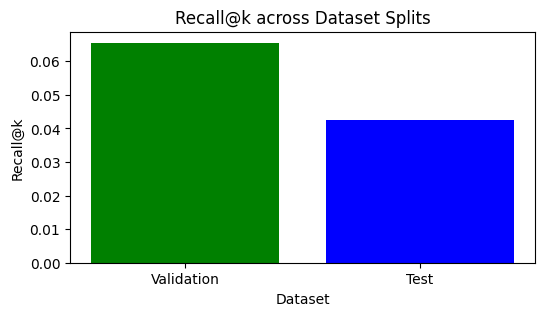

In [ ]:
results = {
    "Validation": val_metrics,
    "Test": test_metrics
}

performance = ['precision@k', 'recall@k']

for metric in performance:
    values = [results[split][metric] for split in results]
    
    plt.figure(figsize=(6, 3))
    plt.bar(results.keys(), values, color=['green', 'blue'])
    plt.title(f"{metric.capitalize()} across Dataset Splits")
    plt.ylabel(metric.capitalize())
    plt.xlabel("Dataset")
    plt.show()